In [65]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
data = pd.read_csv("ecommerce_clothing_sales_dataset.csv")
data.head()
# print(data.head())
# import os
# print(os.getcwd())

,order_id,transaction_id,order_date,customer_id,customer_age,customer_gender,customer_country,customer_city,customer_segment,is_returning_customer,...,customer_rating,review_count,campaign_id,promo_code,seasonal_tag,days_since_last_purchase,average_order_value,customer_acquisition_cost,timezone,currency
0,ORD000001,TXN00000001,2024-07-19 21:59:24.644036,CUST000913,19,Other,Japan,Sydney,Regular,True,...,4.8,172,NaN,PROMO25,Spring,184.0,261.87,64.34,EST,JPY
1,ORD000002,TXN00000002,2024-10-19 21:59:24.644036,CUST004393,25,Female,Canada,Brussels,Budget,False,...,5.0,327,CAMP029,PROMO44,Fall,NaN,260.71,79.84,PST,INR
2,ORD000003,TXN00000003,2025-05-26 21:59:24.644036,CUST002585,43,Female,Canada,Madrid,Budget,True,...,3.4,239,CAMP071,PROMO01,Back-to-School,59.0,220.43,58.33,GMT,INR
3,ORD000004,TXN00000004,2024-07-18 21:59:24.644036,CUST002787,25,Female,Sweden,Milan,VIP,True,...,4.8,43,CAMP009,PROMO49,Holiday,65.0,82.10,52.78,JST,EUR
4,ORD000005,TXN00000005,2025-01-27 21:59:24.644036,CUST004323,56,Female,Spain,Brussels,Regular,False,...,4.7,292,CAMP032,PROMO31,NaN,NaN,151.76,18.49,IST,CAD


In [67]:
data.shape


(1000, 52)

In [68]:
data.columns


Index(['order_id', 'transaction_id', 'order_date', 'customer_id',
       'customer_age', 'customer_gender', 'customer_country', 'customer_city',
       'customer_segment', 'is_returning_customer', 'customer_lifetime_value',
       'product_id', 'product_name', 'brand', 'category', 'subcategory',
       'size', 'color', 'material', 'unit_price', 'quantity',
       'discount_percentage', 'discount_amount', 'subtotal', 'tax_amount',
       'shipping_cost', 'total_amount', 'stock_quantity', 'warehouse_location',
       'payment_method', 'shipping_method', 'order_status', 'shipping_date',
       'delivery_date', 'device_type', 'traffic_source',
       'session_duration_seconds', 'page_views', 'cart_abandonment',
       'profit_margin_percent', 'cost_of_goods', 'return_rate_percent',
       'customer_rating', 'review_count', 'campaign_id', 'promo_code',
       'seasonal_tag', 'days_since_last_purchase', 'average_order_value',
       'customer_acquisition_cost', 'timezone', 'currency'],
     

In [69]:
data["revenue"]=data["quantity"]+data["unit_price"]

In [70]:
data.head()

,order_id,transaction_id,order_date,customer_id,customer_age,customer_gender,customer_country,customer_city,customer_segment,is_returning_customer,...,review_count,campaign_id,promo_code,seasonal_tag,days_since_last_purchase,average_order_value,customer_acquisition_cost,timezone,currency,revenue
0,ORD000001,TXN00000001,2024-07-19 21:59:24.644036,CUST000913,19,Other,Japan,Sydney,Regular,True,...,172,NaN,PROMO25,Spring,184.0,261.87,64.34,EST,JPY,132.84
1,ORD000002,TXN00000002,2024-10-19 21:59:24.644036,CUST004393,25,Female,Canada,Brussels,Budget,False,...,327,CAMP029,PROMO44,Fall,NaN,260.71,79.84,PST,INR,66.99
2,ORD000003,TXN00000003,2025-05-26 21:59:24.644036,CUST002585,43,Female,Canada,Madrid,Budget,True,...,239,CAMP071,PROMO01,Back-to-School,59.0,220.43,58.33,GMT,INR,147.43
3,ORD000004,TXN00000004,2024-07-18 21:59:24.644036,CUST002787,25,Female,Sweden,Milan,VIP,True,...,43,CAMP009,PROMO49,Holiday,65.0,82.10,52.78,JST,EUR,114.47
4,ORD000005,TXN00000005,2025-01-27 21:59:24.644036,CUST004323,56,Female,Spain,Brussels,Regular,False,...,292,CAMP032,PROMO31,NaN,NaN,151.76,18.49,IST,CAD,183.97


In [71]:
data["revenue"].describe()

count    1000.000000
mean      260.981800
std       136.923438
min        19.460000
25%       140.805000
50%       264.545000
75%       372.845000
max       503.940000
Name: revenue, dtype: float64

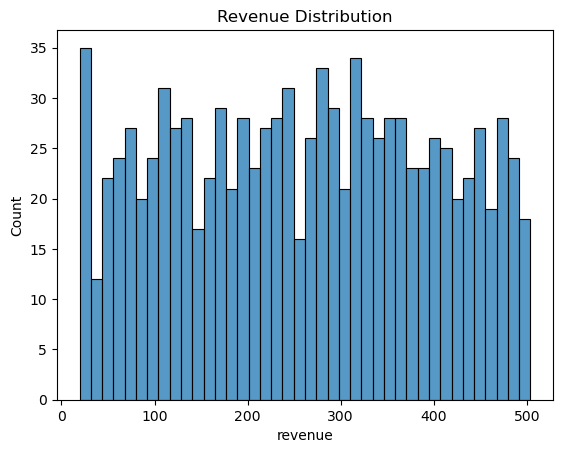

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data["revenue"], bins=40)
plt.title("Revenue Distribution")
plt.show()

In [73]:
data[["quantity","unit_price","revenue"]].corr()

,quantity,unit_price,revenue
quantity,1.000000,0.001068,0.011427
unit_price,0.001068,1.000000,0.999946
revenue,0.011427,0.999946,1.000000


In [74]:
data[["quantity","unit_price","revenue"]].head()


,quantity,unit_price,revenue
0,5,127.84,132.84
1,3,63.99,66.99
2,5,142.43,147.43
3,3,111.47,114.47
4,5,178.97,183.97


In [75]:
data["order_date"] = pd.to_datetime(data["order_date"])

In [76]:
data["month"] = data["order_date"].dt.month
data["day"] = data["order_date"].dt.day
data["year"] = data["order_date"].dt.year

In [77]:
data[["order_date","month","day","year"]].head()

,order_date,month,day,year
0,2024-07-19 21:59:24.644036,7,19,2024
1,2024-10-19 21:59:24.644036,10,19,2024
2,2025-05-26 21:59:24.644036,5,26,2025
3,2024-07-18 21:59:24.644036,7,18,2024
4,2025-01-27 21:59:24.644036,1,27,2025


In [78]:
features = [
    "quantity",
    "unit_price",
    "discount_percentage",
    "customer_age",
    "profit_margin_percent"
]
X = data[features]
y = data["total_amount"]

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [81]:
from sklearn.metrics import r2_score
print("Model Accuracy:", r2_score(y_test, predictions))

Model Accuracy: 0.8744604297220492


In [82]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [83]:
print("Random Forest Accuracy:", r2_score(y_test, rf_predictions))

Random Forest Accuracy: 0.9928267188452596


In [84]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
print("XGBoost Accuracy:", r2_score(y_test, xgb_predictions))

XGBoost Accuracy: 0.9909890523903452


In [85]:
print("Linear Regression:", r2_score(y_test, predictions))
print("Random Forest:", r2_score(y_test, rf_predictions))
print("XGBoost:", r2_score(y_test, xgb_predictions))

Linear Regression: 0.8744604297220492
Random Forest: 0.9928267188452596
XGBoost: 0.9909890523903452


In [86]:
import joblib
joblib.dump(rf_model, "sales_estimator_model.pkl")

['sales_estimator_model.pkl']

In [89]:
def predict_sales(quantity, price, age, discount, margin):

    input_data = pd.DataFrame([[quantity, price, age, discount, margin]], columns=features)

    prediction = rf_model.predict(input_data)

    return prediction[0]

In [90]:
predict_sales(3,120,30,10,7)

303.3294999999999